In [1]:
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
import RA_funcs as rf
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew
import Scope_funcs as sf
import pyarrow as pa

imports work
imports work


In [2]:
# plots the energy profile vs the x axis and fits to gaussian
def E_vs_X_scope_gaussian_fit(hit_data, chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, Normalize=False, plane="false"):

    title = ("Shower Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")

    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data,1/chi2, chi2)
    y_max, y_min

    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((hit_data_chi2.tele.y < y_max) & (hit_data_chi2.tele.y > y_min))]
    data = data[ak.num(data.tele) == 1]


    # compute X and E
    X1 = -ak.to_numpy(ak.mean(data.tele.x, axis=1))
    X = bin_size * np.round(X1 / bin_size)
    
    if plane != "false":
        E_plane = data.hits[data.hits.plane == plane]
        E = ak.sum(E_plane.amp, axis=1)
        title = (f"Plane {plane + 1} Average Energy vs Scope X Position\n"
            r"Fit to: $y = c - A\cdot exp(\frac{-(x - \mu)^2}{2 \sigma^2})$")
    else:
        E = ak.sum(data.hits.amp, axis=1)


    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])

    # Fitting

    #  Gaussian model 
    def gaussian_linear(x, c, A, mu, sigma):
        return c - A * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # initial guesses
    c0 = 6000
    A0 = np.min(amp_m)
    # mu0 = pos_m[np.argmin(amp_m)]
    mu0 = 0
    sigma0 = 3
    # sigma0 = (np.max(pos_m) - np.min(pos_m)) / 6


    # fit
    popt, pcov = curve_fit(gaussian_linear, pos_m, amp_m, p0=[c0, A0, mu0, sigma0], sigma=err_m, absolute_sigma=True)

    # fitted values
    c_fit, A_fit, mu_fit, sigma_fit = popt
    
    # uncertainties
    perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties
    c_err,  A_err, mu_err, sigma_err = perr

    # return the fitting results if needed
    if return_param:
        return popt, perr


    # chi2
    residuals = amp_m - gaussian_linear(pos_m, *popt)

    # avoid division by zero if any std are 0
    mask_err = err_m > 0
    chi2_val = np.sum((residuals[mask_err] / err_m[mask_err])**2)

    # number of points used in chi2
    N = np.sum(mask_err)
    
    # number of fit params (c, m, A, mu, sigma) = 5
    p = len(popt)
    ndof = N - p
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan

    # plot
    fig, ax = plt.subplots()
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="data")

    # make a smooth fitted function
    x_fit = np.linspace(np.min(pos_m), np.max(pos_m), 500)
    y_fit = gaussian_linear(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label="Gaussian fit", zorder=10)

    # build textbox string
    textstr = "\n".join([
        r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
        r"$c = %.3f \pm %.3f$" % (c_fit, c_err),
        r"$A = %.3f \pm %.3f$" % (A_fit, A_err),
        r"$\mu = %.3f \pm %.3f$" % (mu_fit, mu_err),
        r"$\sigma = %.3f \pm %.3f$" % (sigma_fit, sigma_err),
    ])

    # add textbox (axes coordinates: 0..1)
    ax.text(
        0.65, 0.36, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    ax.grid(True)
    ax.set_xlabel("X Scope")
    ax.set_ylabel("Energy [ADC] (avg ± std)")
    # ax.set_title(r"Average Energy vs Scope X Position \n Fit to $y = m \cdot x + c - A\cdot e^{\frac{-(x - \mu)^2}{(2 \sigma^2)}}$")
    ax.set_title(title)

    ax.legend(loc="upper left")
    # leg = ax.legend(loc="upper right", title=textstr, frameon=True)
    
    if Normalize:
        import matplotlib.ticker as ticker        
        # Define the division logic (e.g., divide by 1000)
        ax.set_yticks(np.linspace(0, c_fit, 11))
        formatter = ticker.FuncFormatter(lambda x, pos: f'{x/c_fit:.2f}')
        ax.yaxis.set_major_formatter(formatter)

    plt.show()



In [3]:
# get the gap parameters for each layer
def gap_per_layer(scope_data,chi2, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4):

    # get the parameters per plane
    c_list = []
    c_err_list = []
    A_list = []
    A_err_list = []
    mu_list = []
    mu_err_list = []

    for plane in range(0,8):
        
        popt, perr = E_vs_X_scope_gaussian_fit(scope_data, chi2, y_min, y_max, x_min, x_max, bin_size, plane=plane, return_param=True)

        c_fit, c_err = popt[0], perr[0]
        A_fit, A_err = popt[1], perr[1]
        mu_fit, mu_err = popt[2], perr[2]

        c_list.append(c_fit)
        c_err_list.append(c_err)
        A_list.append(A_fit)
        A_err_list.append(A_err)
        mu_list.append(mu_fit)
        mu_err_list.append(mu_err)

    planes = 1 + np.arange(len(c_list))  # 0..7

    fig, axs = plt.subplots(2, 1, sharex=True)

    # c
    axs[0].errorbar(planes, c_list, yerr=c_err_list, fmt='o-', capsize=3)
    axs[0].set_ylabel("c")
    axs[0].grid(True, alpha=0.3)

    # A
    axs[1].errorbar(planes, A_list, yerr=A_err_list, fmt='o-', capsize=3, color="r")
    axs[1].set_ylabel("A")
    axs[1].grid(True, alpha=0.3)
    axs[1].set_xlabel("Plane")

    fig.suptitle("Gap fit parameters per plane")
    plt.tight_layout()
    plt.show()



<span style="font-family: arial; font-size:25px; color:pink">

Create Run Data With Dead Pad Correction

In [4]:
# run number
def create_pad_corrected_data(run_number, correction_radius=6, aligned=True):

    # call the data
    if aligned:
        data_scope = sf.get_ROOT_data_zip_Aligned(run_number)
    else:
        data_scope = sf.DUT_TELE_merge(run_number)

    # create the corrected data
    path = f"TB_FIRE/TB_reco/TB_FIRE_{run_number}_raw_reco_diagnostics.root"
    data_scope_corrected = rf.reconstruct_data_all_dead_pads(data_scope, correction_radius, path)

    # Save to a file
    ak.to_parquet(data_scope_corrected, f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")

    return

In [5]:
# create_pad_corrected_data(1080, correction_radius=7, aligned=False)

<span style="font-family: arial; font-size:25px; color:pink">

Read Pas Corrected Data and Plot Gap

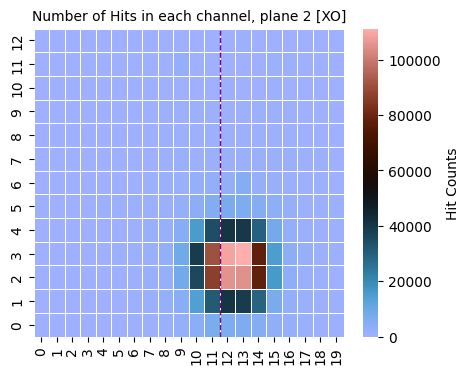

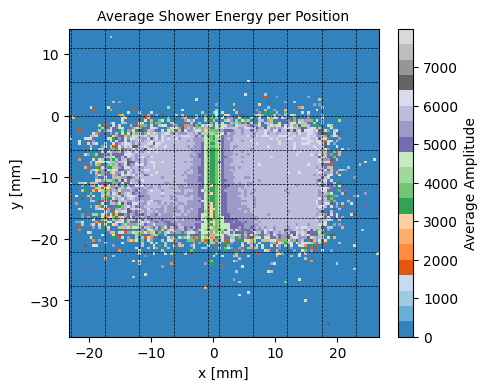

hi
-15.88975113438564 -5.889751134385641


/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


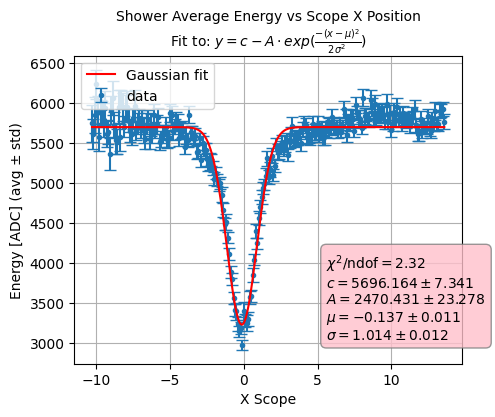

In [ ]:
# run number
run_number = 1089

# plotting parameters
plt.rcParams.update({
        "figure.figsize": (5, 4),
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    })

# Run Data
data_scope_corrected = ak.from_parquet(f"TB_FIRE/Pad_Corrected_Data/run_{run_number}_pad_corrected.parquet")

# plot hits colormap
rf.hits_amount_colormap_single_plane(data_scope_corrected.hits, 2)

# plot xy amp colormap
x_center, y_center = sf.avg_energy_scope_colormap(data_scope_corrected, x_shift=-3, amp_thresh=8000)

# plot gap gaussian fit
y_min, y_max = y_center-5, y_center+5
x_min, x_max = x_center-12, x_center+12
print(y_min,y_max)
E_vs_X_scope_gaussian_fit(data_scope_corrected, 1.1, y_min, y_max, x_min, x_max, bin_size=0.1)

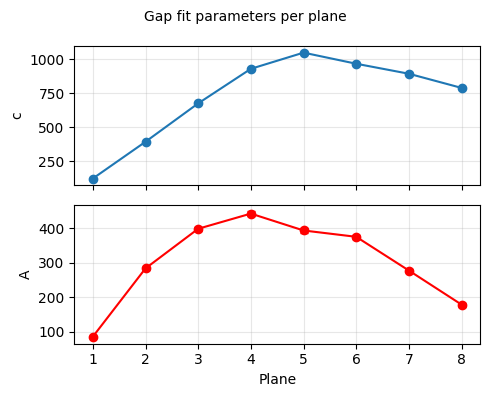

In [32]:
gap_per_layer(data_scope_corrected, 1.1, y_min, y_max, x_min, x_max, bin_size=0.5)